# Input - Import kaggle datasets

In [49]:
# Hulu 
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/hulu-movies-and-tv-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/hulu-movies-and-tv-shows


In [50]:
# netflix
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/netflix-shows


In [51]:
# amazon
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/amazon-prime-movies-and-tv-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/amazon-prime-movies-and-tv-shows


In [52]:
# disney
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/disney-movies-and-tv-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/disney-movies-and-tv-shows


In [53]:
# with posters
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisemalti/movies-dataset-with-posters")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/movies-dataset-with-posters


In [54]:
# 5000 movies
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tmdb-movie-metadata


In [55]:
# more data for posters
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows


# Data Understanding

In [56]:
import pandas as pd
import numpy as np

m = pd.read_csv('/kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv')
c = pd.read_csv('/kaggle/input/tmdb-movie-metadata/tmdb_5000_credits.csv')
p = pd.read_csv('/kaggle/input/movies-dataset-with-posters/poster.csv')

In [57]:
m.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [58]:
c.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')

In [59]:
p.columns

Index(['title', 'poster'], dtype='object')

In [60]:
m.head(5)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [61]:
import json

all_genres = set()

for genres_str in m['genres']:
    genres_list = json.loads(genres_str)
    
    for genre in genres_list:
        all_genres.add(genre['name'])

print(sorted(list(all_genres)))

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [62]:
# find genres for 'Toy Story'

import json

# Get the text string from the specific row
# .iloc[0] grabs the actual value out of the dataframe wrapper
json_text = m[m['original_title'] == 'Toy Story']['genres'].iloc[0]

# 2. Convert the text string to a Python List
data = json.loads(json_text)

# 3. Extract just the names
genre_names = [item['name'] for item in data]

print(genre_names)

['Animation', 'Comedy', 'Family']


In [63]:
full_description = m[m["title"]=="Toy Story"]["overview"].values[0]
print(full_description)

Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.


In [64]:
p.head(5)

,title,poster
0,Spider-Man: No Way Home,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,The Batman,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,No Exit,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,Encanto,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,The King's Man,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


# Data Loading (Movies + Credits + Posters + IMDB + Disney + Amazon + Netflix + Hulu)

In [65]:
# ==========================================
# DATA LOADING (Restored: Streaming + Safe AI Vision)
# ==========================================
import json
import pandas as pd
import os

In [66]:
# ---------------------------------------------------------
# LOAD MAIN DATASETS
# ---------------------------------------------------------
movies = pd.read_csv('/kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv')
credits = pd.read_csv('/kaggle/input/tmdb-movie-metadata/tmdb_5000_credits.csv')
    
credits.rename(columns={'movie_id': 'id'}, inplace=True)
movies = movies.merge(credits[['id', 'cast', 'crew']], on='id')

In [67]:
# ---------------------------------------------------------
# LOAD & MERGE STREAMING DATA (Descriptions)
# ---------------------------------------------------------
def load_streaming_df(path, platform_name):
    try:
        df = pd.read_csv(path)
        # Find description column
        desc_col = 'description' if 'description' in df.columns else 'overview'
        if desc_col not in df.columns: return pd.DataFrame(), set()
            
        # Normalize title
        df['match_title'] = df['title'].str.lower().str.strip()
        df = df.rename(columns={desc_col: f'{platform_name}_desc'})
        return df[['match_title', f'{platform_name}_desc']], set(df['match_title'])
    except:
        return pd.DataFrame(), set()

netflix_df, netflix_titles = load_streaming_df('/kaggle/input/netflix-shows/netflix_titles.csv', 'netflix')
disney_df, disney_titles   = load_streaming_df('/kaggle/input/disney-movies-and-tv-shows/disney_plus_titles.csv', 'disney')
amazon_df, amazon_titles   = load_streaming_df('/kaggle/input/amazon-prime-movies-and-tv-shows/amazon_prime_titles.csv', 'amazon')
hulu_df, hulu_titles       = load_streaming_df('/kaggle/input/hulu-movies-and-tv-shows/hulu_titles.csv', 'hulu')

In [68]:
# ---------------------------------------------------------
# Merge descriptions (more overview information)
# ---------------------------------------------------------
movies['match_title'] = movies['original_title'].str.lower().str.strip()
movies = movies.merge(netflix_df, on='match_title', how='left')
movies = movies.merge(disney_df, on='match_title', how='left')
movies = movies.merge(amazon_df, on='match_title', how='left')
movies = movies.merge(hulu_df, on='match_title', how='left')

In [69]:
# ---------------------------------------------------------
# Create 'streaming_desc'
# ---------------------------------------------------------
def combine_descriptions(row):
    descs = []
    if pd.notna(row.get('netflix_desc')): descs.append(f"Netflix says: {row['netflix_desc']}")
    if pd.notna(row.get('disney_desc')):  descs.append(f"Disney+ says: {row['disney_desc']}")
    if pd.notna(row.get('amazon_desc')):  descs.append(f"Amazon says: {row['amazon_desc']}")
    if pd.notna(row.get('hulu_desc')):    descs.append(f"Hulu says: {row['hulu_desc']}")
    return " ".join(descs)

movies['streaming_desc'] = movies.apply(combine_descriptions, axis=1)

In [70]:
# ---------------------------------------------------------
# LOAD POSTERS data
# ---------------------------------------------------------
try:
    posters_a = pd.read_csv('/kaggle/input/movies-dataset-with-posters/poster.csv')
except:
    posters_a = pd.read_csv('/kaggle/input/movies-dataset-with-posters/movie_posters.csv')
    
imdb_data = pd.read_csv('/kaggle/input/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv')
    
# Merge Posters
p_col = 'poster' if 'poster' in posters_a.columns else 'Poster'
t_col = 'title' if 'title' in posters_a.columns else 'Title'
posters_a = posters_a[[t_col, p_col]].drop_duplicates(subset=[t_col])
    
movies = movies.merge(posters_a, left_on='original_title', right_on=t_col, how='left')
movies = movies.merge(imdb_data[['Series_Title', 'Poster_Link']], left_on='original_title', right_on='Series_Title', how='left')
movies['Poster'] = movies[p_col].fillna(movies['Poster_Link'])

In [71]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,netflix_desc,disney_desc,amazon_desc,hulu_desc,streaming_desc,title_y,poster,Series_Title,Poster_Link,Poster
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,NaN,A man embarks on an adventure to an exotic wor...,NaN,NaN,Disney+ says: A man embarks on an adventure to...,Avatar,https://image.tmdb.org/t/p/original/jRXYjXNq0C...,Avatar,https://m.media-amazon.com/images/M/MV5BMTYwOT...,https://image.tmdb.org/t/p/original/jRXYjXNq0C...
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,NaN,An alliance forms to rescue Captain Jack Sparr...,NaN,NaN,Disney+ says: An alliance forms to rescue Capt...,Pirates of the Caribbean: At World's End,https://image.tmdb.org/t/p/original/2YMnBRh8F6...,NaN,NaN,https://image.tmdb.org/t/p/original/2YMnBRh8F6...
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,NaN,NaN,NaN,NaN,,Spectre,https://image.tmdb.org/t/p/original/zj8ongFhtW...,NaN,NaN,https://image.tmdb.org/t/p/original/zj8ongFhtW...
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,NaN,NaN,NaN,NaN,,The Dark Knight Rises,https://image.tmdb.org/t/p/original/85cWkCVfti...,The Dark Knight Rises,https://m.media-amazon.com/images/M/MV5BMTk4OD...,https://image.tmdb.org/t/p/original/85cWkCVfti...
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"One minute, Civil War veteran John Carter is e...",A former military captain is inexplicably tran...,NaN,NaN,"Netflix says: One minute, Civil War veteran Jo...",John Carter,https://image.tmdb.org/t/p/original/7GSSyUUgUE...,NaN,NaN,https://image.tmdb.org/t/p/original/7GSSyUUgUE...


In [72]:
movies. shape

(4805, 33)

In [ ]:
# data for the poster desc process
df = pd.DataFrame(movies)

df.to_csv('my_data.csv', index=False, encoding='utf-8-sig')

# EDA

## Distribution of Movie Genres

/tmp/ipykernel_55/2461384662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(genre_counts.values()), y=list(genre_counts.keys()), palette='pastel')


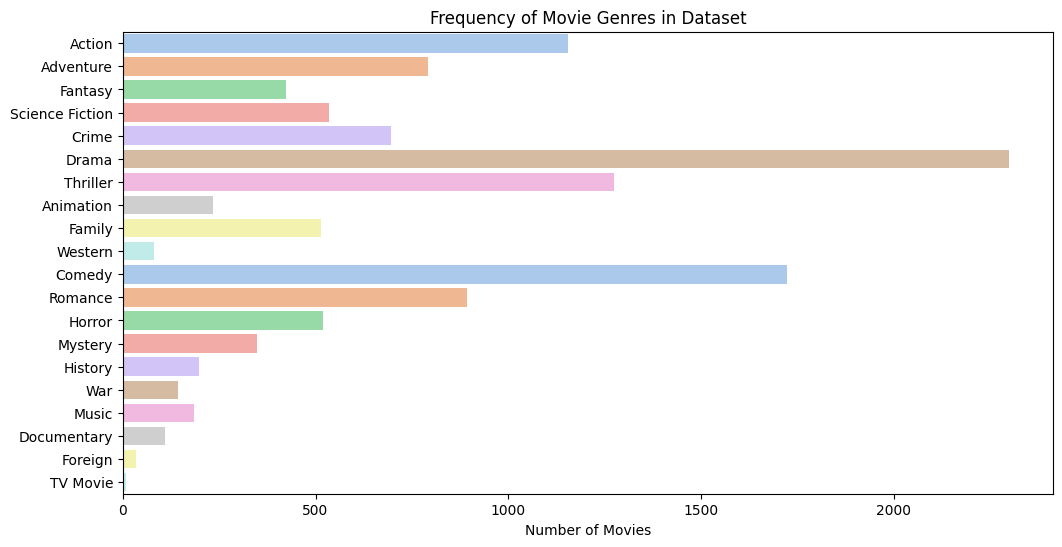

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Parse genres and count them
genre_counts = Counter()
for genres_str in movies['genres']:
    genres_list = json.loads(genres_str)
    for genre in genres_list:
        genre_counts[genre['name']] += 1

# 2. Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=list(genre_counts.values()), y=list(genre_counts.keys()), palette='pastel')
plt.title('Frequency of Movie Genres in Dataset')
plt.xlabel('Number of Movies')
plt.show()

## Streaming Platform Coverage

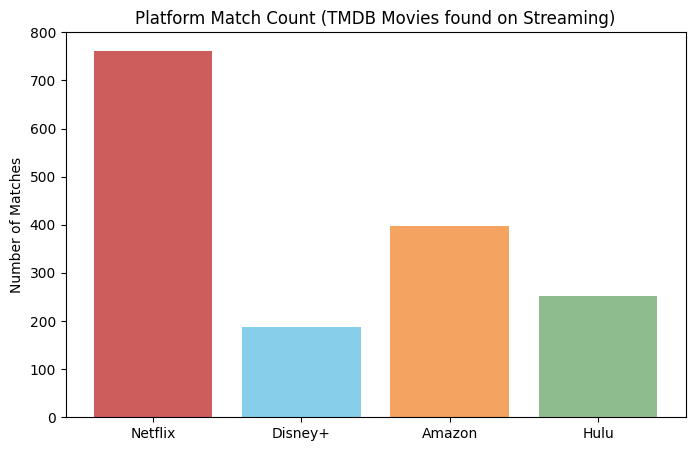

In [75]:
# Check how many movies from the TMDB list appear on each platform
platform_coverage = {
    'Netflix': movies['netflix_desc'].notna().sum(),
    'Disney+': movies['disney_desc'].notna().sum(),
    'Amazon': movies['amazon_desc'].notna().sum(),
    'Hulu': movies['hulu_desc'].notna().sum()
}

plt.figure(figsize=(8, 5))
plt.bar(platform_coverage.keys(), platform_coverage.values(), color=['IndianRed', 'SkyBlue', 'SandyBrown', 'DarkSeaGreen'])
plt.title('Platform Match Count (TMDB Movies found on Streaming)')
plt.ylabel('Number of Matches')
plt.show()

## Top Rated Movies & Popularity

In [ ]:
# Filter for movies with at least 500 votes to ensure quality ratings
top_rated = movies[movies['vote_count'] > 500].sort_values(by='vote_average', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_rated, x='vote_average', y='original_title', palette='pastel')
plt.xlim(7, 10)
plt.title('Top 5 Highest Rated Movies (Min. 500 Votes)')
plt.show()

## Visualizing Poster Availability

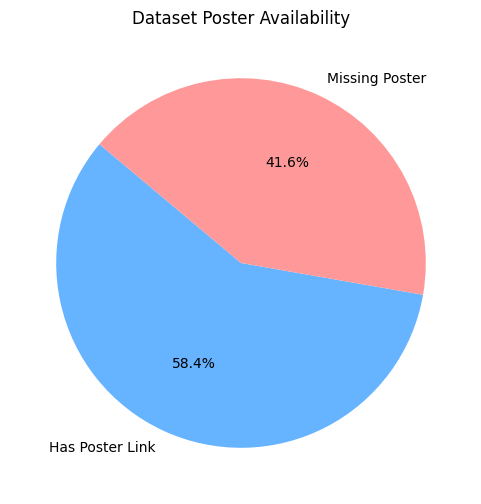

In [77]:
# Updated Pie Chart Code
poster_status = movies['Poster'].isna().value_counts()
labels = ['Has Poster Link', 'Missing Poster']

plt.figure(figsize=(6, 6))
# Fixed the autopct string here:
plt.pie(poster_status, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title('Dataset Poster Availability')
plt.show()

# Load data with poster description and Merge datasets

In [78]:
# Load the datasets
df1 = pd.read_csv('/kaggle/input/dataset-with-poster-desc/cleaned_merged_movies.csv')
df2 = movies.copy()

In [79]:
print(df1.shape)
print(df2.shape)

(2800, 35)
(4805, 33)


In [80]:
df1.columns

Index(['Title', 'AI POSTER DESC', 'budget', 'genres', 'homepage', 'id',
       'keywords', 'original_language', 'original_title', 'overview',
       'popularity', 'production_companies', 'production_countries',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'status',
       'tagline', 'title_x', 'vote_average', 'vote_count', 'cast', 'crew',
       'match_title', 'netflix_desc', 'disney_desc', 'amazon_desc',
       'hulu_desc', 'streaming_desc', 'title_y', 'poster', 'Series_Title',
       'Poster_Link', 'Poster'],
      dtype='object')

In [81]:
df2.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'cast', 'crew', 'match_title', 'netflix_desc',
       'disney_desc', 'amazon_desc', 'hulu_desc', 'streaming_desc', 'title_y',
       'poster', 'Series_Title', 'Poster_Link', 'Poster'],
      dtype='object')

In [82]:
# Identify the new data we want from the second file
# Based on your indices, 'AI POSTER DESC' and 'Title' are the primary new additions.
# We also include 'match_title' as the key to merge on.
cols_to_bring = ['match_title', 'AI POSTER DESC', 'Title']

In [83]:
# Perform the merge on 'match_title'
# We use 'left' to keep all movies from your main cleaned dataset.
merged_df = pd.merge(df2, df1[cols_to_bring].drop_duplicates('match_title'), 
                     on='match_title', 
                     how='left')

In [84]:
merged_df

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,amazon_desc,hulu_desc,streaming_desc,title_y,poster,Series_Title,Poster_Link,Poster,AI POSTER DESC,Title
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,NaN,NaN,Disney+ says: A man embarks on an adventure to...,Avatar,https://image.tmdb.org/t/p/original/jRXYjXNq0C...,Avatar,https://m.media-amazon.com/images/M/MV5BMTYwOT...,https://image.tmdb.org/t/p/original/jRXYjXNq0C...,"The movie poster for ""Avatar"" features a blue-...",Avatar
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,NaN,NaN,Disney+ says: An alliance forms to rescue Capt...,Pirates of the Caribbean: At World's End,https://image.tmdb.org/t/p/original/2YMnBRh8F6...,NaN,NaN,https://image.tmdb.org/t/p/original/2YMnBRh8F6...,"A movie poster for ""Pirates of the Caribbean: ...",Pirates of the Caribbean: At World's End
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,NaN,NaN,,Spectre,https://image.tmdb.org/t/p/original/zj8ongFhtW...,NaN,NaN,https://image.tmdb.org/t/p/original/zj8ongFhtW...,"A man in a white tuxedo, holding a gun, stands...",Spectre
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,NaN,NaN,,The Dark Knight Rises,https://image.tmdb.org/t/p/original/85cWkCVfti...,The Dark Knight Rises,https://m.media-amazon.com/images/M/MV5BMTk4OD...,https://image.tmdb.org/t/p/original/85cWkCVfti...,"A dramatic movie poster for ""The Dark Knight R...",The Dark Knight Rises
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,NaN,NaN,"Netflix says: One minute, Civil War veteran Jo...",John Carter,https://image.tmdb.org/t/p/original/7GSSyUUgUE...,NaN,NaN,https://image.tmdb.org/t/p/original/7GSSyUUgUE...,"The movie poster for ""John Carter"" features a ...",John Carter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4800,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]",...,NaN,NaN,,El Mariachi,https://image.tmdb.org/t/p/original/zRh7K4SV1x...,NaN,NaN,https://image.tmdb.org/t/p/original/zRh7K4SV1x...,A man in a black suit and boots walks down a y...,El Mariachi
4801,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],...,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4802,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"":

In [85]:
merged_df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'cast', 'crew', 'match_title', 'netflix_desc',
       'disney_desc', 'amazon_desc', 'hulu_desc', 'streaming_desc', 'title_y',
       'poster', 'Series_Title', 'Poster_Link', 'Poster', 'AI POSTER DESC',
       'Title'],
      dtype='object')

# Continue with Pre-Processing  

## Helper functions

In [86]:
def parse_json_col(json_str):
    try:
        data = json.loads(json_str)
        return ", ".join([x['name'] for x in data])
    except:
        return ""

def get_top_cast(json_str, k=3):
    try:
        data = json.loads(json_str)
        return ", ".join([x['name'] for x in data[:k]])
    except:
        return ""

def get_platform_text(row):
    platforms = []
    if row.get('on_netflix'): platforms.append("Netflix")
    if row.get('on_disney'): platforms.append("Disney+")
    if row.get('on_amazon'): platforms.append("Amazon Prime")
    if row.get('on_hulu'):   platforms.append("Hulu")
    return "Available on " + " & ".join(platforms) if platforms else ""

## Enrichment (Flags + Text)

In [87]:
merged_df['on_netflix'] = merged_df['match_title'].isin(netflix_titles)
merged_df['on_disney']  = merged_df['match_title'].isin(disney_titles)
merged_df['on_amazon']  = merged_df['match_title'].isin(amazon_titles)
merged_df['on_hulu']    = merged_df['match_title'].isin(hulu_titles)

merged_df['genre_text'] = merged_df['genres'].apply(parse_json_col)
merged_df['keyword_text'] = merged_df['keywords'].apply(parse_json_col)
merged_df['cast_text'] = merged_df['cast'].apply(lambda x: get_top_cast(x, k=5))
merged_df['stream_text'] = merged_df.apply(get_platform_text, axis=1)

## Final Search Text (Cleaned Syntax)

In [88]:
# Use .astype(str) to avoid errors if any column contains NaNs
merged_df['search_text'] = (
    "Title: " + merged_df['original_title'].astype(str) + "; " +
    "Genres: " + merged_df['genre_text'].astype(str) + "; " +
    "Keywords: " + merged_df['keyword_text'].astype(str) + "; " +
    "Cast: " + merged_df['cast_text'].astype(str) + "; " +
    "Platform: " + merged_df['stream_text'].astype(str) + "; " +
    "Overview: " + merged_df['overview'].astype(str) + "; " +
    "Streaming Details: " + merged_df['streaming_desc'].astype(str) + "; " +
    "Poster Description: " + merged_df['AI POSTER DESC'].astype(str)
)

# Check the data before next step

In [89]:
merged_df

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,Title,on_netflix,on_disney,on_amazon,on_hulu,genre_text,keyword_text,cast_text,stream_text,search_text
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Avatar,False,True,False,False,"Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...","Sam Worthington, Zoe Saldana, Sigourney Weaver...",Available on Disney+,"Title: Avatar; Genres: Action, Adventure, Fant..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,Pirates of the Caribbean: At World's End,False,True,False,False,"Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...","Johnny Depp, Orlando Bloom, Keira Knightley, S...",Available on Disney+,Title: Pirates of the Caribbean: At World's En...
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,Spectre,False,False,False,False,"Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...","Daniel Craig, Christoph Waltz, Léa Seydoux, Ra...",,"Title: Spectre; Genres: Action, Adventure, Cri..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,The Dark Knight Rises,False,False,False,False,"Action, Crime, Drama, Thriller","dc comics, crime fighter, terrorist, secret id...","Christian Bale, Michael Caine, Gary Oldman, An...",,"Title: The Dark Knight Rises; Genres: Action, ..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,John Carter,True,True,False,False,"Action, Adventure, Science Fiction","based on novel, mars, medallion, space travel,...","Taylor Kitsch, Lynn Collins, Samantha Morton, ...",Available on Netflix & Disney+,"Title: John Carter; Genres: Action, Adventure,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4800,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]",...,El Mariachi,False,False,False,False,"Action, Crime, Thriller","united states–mexico barrier, legs, arms, pape...","Carlos Gallardo, Jaime de Hoyos, Peter Marquar...",,"Title: El Mariachi; Genres: Action, Crime, Thr..."
4801,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],...,NaN,False,False,False,False,"Comedy, Romance",,"Edward Burns, Kerry Bishé, Marsha Dietlein, Ca...",,"Title: Newlyweds; Genres: Comedy, Romance; Key..."
4802,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18

In [90]:
merged_df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'cast', 'crew', 'match_title', 'netflix_desc',
       'disney_desc', 'amazon_desc', 'hulu_desc', 'streaming_desc', 'title_y',
       'poster', 'Series_Title', 'Poster_Link', 'Poster', 'AI POSTER DESC',
       'Title', 'on_netflix', 'on_disney', 'on_amazon', 'on_hulu',
       'genre_text', 'keyword_text', 'cast_text', 'stream_text',
       'search_text'],
      dtype='object')

# Drop irrelevant columns

In [91]:
cols_to_drop = [
    'title_x', 'title_y', 'Title', 'Series_Title', 'match_title',
    'genres', 'keywords', 'cast', 'crew', 
    'genre_text', 'keyword_text', 'cast_text', 'stream_text',
    'netflix_desc', 'disney_desc', 'amazon_desc', 'hulu_desc',
    'poster', 'Poster_Link','streaming_desc','AI POSTER DESC'
]

movies_cleaned = merged_df.drop(columns=cols_to_drop, errors='ignore')


print(movies_cleaned.columns)

Index(['budget', 'homepage', 'id', 'original_language', 'original_title',
       'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'vote_average', 'vote_count',
       'Poster', 'on_netflix', 'on_disney', 'on_amazon', 'on_hulu',
       'search_text'],
      dtype='object')


# Remove duplicates

In [92]:
movies_cleaned.shape

(4805, 23)

In [93]:
duplicate_count = movies_cleaned.duplicated(subset=['original_title']).sum()
print(f"Total duplicate titles found: {duplicate_count}")

# check dupticates
if duplicate_count > 0:
    print("\nExamples of duplicate movies:")
    print(merged_df[merged_df.duplicated(subset=['original_title'], keep=False)]['original_title'].value_counts().head(10))

Total duplicate titles found: 4

Examples of duplicate movies:
original_title
Lost in Space              2
Batman                     2
Out of the Blue            2
The Squid and the Whale    2
Name: count, dtype: int64


In [94]:
# remove one show of the duplicate movies 
movies_cleaned = movies_cleaned.drop_duplicates(subset=['original_title'], keep='first')

# reset index
movies_cleaned.reset_index(drop=True, inplace=True)

print(f"Cleaned! New dataset shape: {movies_cleaned.shape}")

Cleaned! New dataset shape: (4801, 23)


In [95]:
# check ids
duplicate_count = movies_cleaned.duplicated(subset=['id']).sum()
print(f"Total duplicate titles found: {duplicate_count}")

Total duplicate titles found: 0


# save final dataset

In [96]:
movies_cleaned.columns

Index(['budget', 'homepage', 'id', 'original_language', 'original_title',
       'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'vote_average', 'vote_count',
       'Poster', 'on_netflix', 'on_disney', 'on_amazon', 'on_hulu',
       'search_text'],
      dtype='object')

## Movie Dataset - Column Descriptions

| Column | Description |
|--------|-------------|
| budget | The total financial amount spent to produce the movie in USD. |
| homepage | The official web URL for the movie's primary landing page. |
| id | The unique numerical identifier for the movie in the TMDB database. |
| original_language | The primary language in which the movie was originally produced. |
| original_title | The title of the movie in its original language. |
| overview | A brief plot summary or synopsis of the movie's storyline. |
| popularity | A numerical score representing the movie's current trendiness or interest level. |
| production_companies | The studios or companies involved in the production of the movie. |
| production_countries | The countries where the movie was filmed or produced. |
| release_date | The official date when the movie was first released to the public. |
| revenue | The total box office earnings generated by the movie globally. |
| runtime | The total duration of the movie in minutes. |
| spoken_languages | The specific languages spoken by the characters within the movie. |
| status | The current production state of the movie (e.g., Released). |
| tagline | A short, catchy promotional phrase used for marketing purposes. |
| vote_average | The average rating submitted by users. |
| vote_count | The total number of users who have submitted a rating for the movie. |
| Poster | A URL link to the official poster image for the movie. |
| on_netflix | A boolean flag (True/False) indicating if the movie is available on Netflix. |
| on_disney | A boolean flag (True/False) indicating if the movie is available on Disney+. |
| on_amazon | A boolean flag (True/False) indicating if the movie is available on Amazon Prime. |
| on_hulu | A boolean flag (True/False) indicating if the movie is available on Hulu. |
| search_text | A unified string of metadata and descriptions used to power the engine (inc. Title, Genres, Keywords, Cast, Platform, Overview, Streaming Details). |


In [97]:
# Save the result
movies_cleaned.to_csv('final_merged_movies.csv', index=False)

print(f"✅ Pre-proccesing Complete! New shape: {movies_cleaned.shape}")
print(f"✅ Loaded {len(movies_cleaned)} movies.")
print(movies_cleaned.head())

✅ Pre-proccesing Complete! New shape: (4801, 23)
✅ Loaded 4801 movies.
      budget                                      homepage      id  \
0  237000000                   http://www.avatarmovie.com/   19995   
1  300000000  http://disney.go.com/disneypictures/pirates/     285   
2  245000000   http://www.sonypictures.com/movies/spectre/  206647   
3  250000000            http://www.thedarkknightrises.com/   49026   
4  260000000          http://movies.disney.com/john-carter   49529   

  original_language                            original_title  \
0                en                                    Avatar   
1                en  Pirates of the Caribbean: At World's End   
2                en                                   Spectre   
3                en                     The Dark Knight Rises   
4                en                               John Carter   

                                            overview  popularity  \
0  In the 22nd century, a paraplegic Marine is di